In [7]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np

In [2]:
stocks = ['3MINDIA.NS', 'ADANIGREEN.NS', 'AXISBANK.NS', 'RELIANCE.NS', 'BAJFINANCE.NS']
weights = [0.2, 0.2, 0.2, 0.2, 0.2]
end_date = datetime.today()
start_date = end_date - timedelta(days=365*10)

In [4]:
# Download and organize data
price_df = yf.download(stocks, start=start_date, end=end_date)['Close']
returns = price_df.pct_change().dropna()

C:\Users\HP\AppData\Local\Temp\ipykernel_10400\3261697131.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(stocks, start=start_date, end=end_date)['Close']


[*********************100%***********************]  5 of 5 completed


In [5]:
#Portfolio Construction
portfolio_returns = (returns * weights).sum(axis=1)
portfolio_returns.name = 'Portfolio'


In [9]:
#VaR & ES Calculation
VaR_5 = np.percentile(portfolio_returns, 5)
ES_5 = portfolio_returns[portfolio_returns < VaR_5].mean()
print('VaR (5%):', VaR_5*100)
print('ES (5%):', ES_5*100)

VaR (5%): -2.1690981506168954
ES (5%): -3.3315961014001214


In [12]:
#Monte Carlo Simulation
n_sim = 10000
horizon = 10
mc_returns = np.random.normal(portfolio_returns.mean(), portfolio_returns.std(), (n_sim, horizon)).sum(axis=1)
VaR_MC = np.percentile(mc_returns, 5)
ES_MC = mc_returns[mc_returns < VaR_MC].mean()
print('10-Day MC VaR/ES%:', VaR_MC*100, ES_MC*100)

10-Day MC VaR/ES%: -6.733164396590268 -8.711766266407581


In [15]:
#GARCH Volatility Modeli
from arch import arch_model
garch = arch_model(portfolio_returns, p=1, q=1,rescale=False)
garch_res = garch.fit(disp="off")
print(garch_res.summary())
vol_forecast = garch_res.forecast(horizon=10)
print('Next 10-day GARCH Vol forecast:', vol_forecast.variance.iloc[-1].values)

#Rolling Window VaR Backtest (21-day window, 99%, 10-day horizon)
window = 21
rolling_std = portfolio_returns.rolling(window).std()
rolling_VaR = -(rolling_std * 2.33 * np.sqrt(10))
returns_10d = portfolio_returns.rolling(10).sum()
breach = returns_10d < rolling_VaR
violation_rate = breach.mean()
print('Rolling breach rate:', violation_rate*100)

                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Portfolio   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5262.28
Distribution:                  Normal   AIC:                          -10516.6
Method:            Maximum Likelihood   BIC:                          -10494.6
                                        No. Observations:                 1815
Date:                Mon, Oct 27 2025   Df Residuals:                     1814
Time:                        00:35:54   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         1.3392e-03  2.837e-04      4.720  2.359e-06 [7.

In [18]:
#Regulatory Scenario Stress Testing
#Baseline: normal returns
baseline = portfolio_returns.copy()

#Adverse: 2008 Global Financial Crisis scenario (simulate 5 std negative shock)
adverse = portfolio_returns.mean() - 5 * portfolio_returns.std()

#Severely Adverse: COVID-crash analog (simulate 10 std negative shock)
severe = portfolio_returns.mean() - 10 * portfolio_returns.std()

scenarios = pd.Series({'Baseline': baseline.mean()*100, 'Adverse': adverse*100, 'Severe': severe*100})
print(scenarios)

Baseline     0.112949
Adverse     -7.419768
Severe     -14.952484
dtype: float64


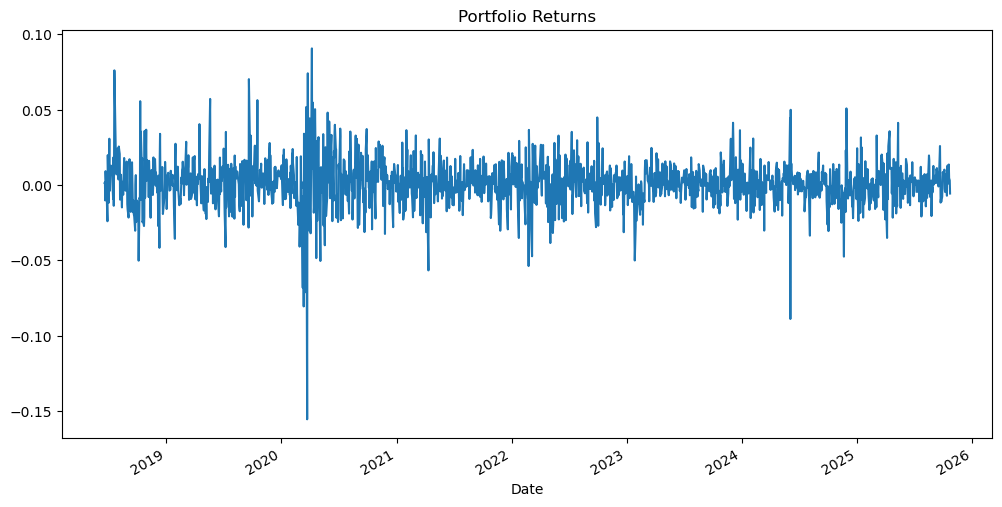

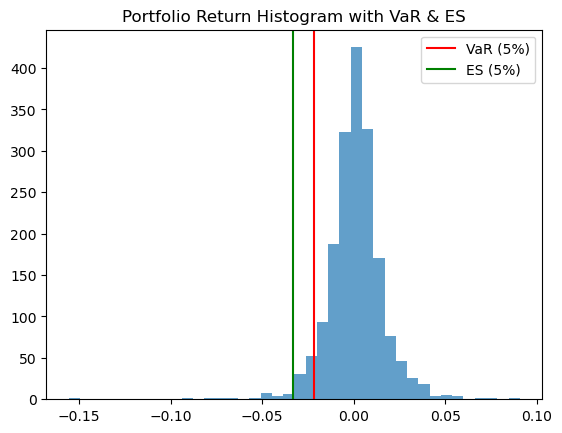

In [17]:
#Visualizations
import matplotlib.pyplot as plt
portfolio_returns.plot(figsize=(12,6), title="Portfolio Returns")
plt.show()
plt.hist(portfolio_returns, bins=40, alpha=0.7)
plt.axvline(VaR_5, color='r', label='VaR (5%)')
plt.axvline(ES_5, color='g', label='ES (5%)')
plt.legend()
plt.title("Portfolio Return Histogram with VaR & ES")
plt.show()